# LSTM — daily candle side

Predict whether **today's** daily candle is long (`close > open`) or short. Inputs are the prior `WINDOW` daily log-return bars, so the call is known before the open.

- **Predicted long:** buy the open, sell the close.
- **Predicted short:** stay flat until the next predicted long.

The equity chart compares that rule with always buying the open and selling the close.

In [39]:
import os
import random
import sys
from pathlib import Path

_ROOT = Path.cwd()
if not (_ROOT / "Data_Handling.py").exists():
    for cand in (_ROOT.parent, _ROOT / "Mario", _ROOT.parent / "Mario"):
        if (cand / "Data_Handling.py").exists():
            _ROOT = cand
            break
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

# Data_Handling builds the Alpaca client at import, so .env has to be in the process first.
for _env in (_ROOT / ".env", _ROOT.parent / ".env"):
    if not _env.exists():
        continue
    for line in _env.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, val = line.split("=", 1)
        os.environ.setdefault(key.strip(), val.strip().strip('"').strip("'"))
    break

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential

from Data_Handling import fetch_alpaca_vbt_data

np.random.seed(SEED)
tf.random.set_seed(SEED)


In [40]:
SYMBOL = "SPY"
START = "2020-01-01"
END = "2026-09-01"
WINDOW = 20
N_FEATS = 5
EPOCHS = 40
BATCH_SIZE = 32
PATIENCE = 6
EMBARGO = 1


In [41]:
df = fetch_alpaca_vbt_data(SYMBOL, START, END, timeframe_unit="Day")
df = df.dropna()
print(df.tail())
print(f"days={len(df):,}  {df.index.min().date()} → {df.index.max().date()}")


field                        Open     High       Low   Close      Volume
timestamp                                                               
2026-08-25 04:00:00+00:00  766.16  766.780  763.0501  765.91  27475227.0
2026-08-26 04:00:00+00:00  764.73  767.350  763.9300  766.08  28810662.0
2026-08-27 04:00:00+00:00  768.50  772.355  767.1600  771.10  34599995.0
2026-08-28 04:00:00+00:00  771.76  775.300  768.3076  769.35  36806117.0
2026-08-31 04:00:00+00:00  767.33  767.995  764.7150  767.05  38903113.0
days=1,674  2020-01-02 → 2026-08-31


## Windows

Each sample's window ends on **yesterday**. The label is today's candle.

In [42]:
def ohlcv_to_log_features(ohlcv: np.ndarray) -> np.ndarray:
    o, h, l, c, v = (ohlcv[:, i] for i in range(5))
    c_prev = np.empty_like(c)
    c_prev[0] = c[0]
    c_prev[1:] = c[:-1]
    v_prev = np.empty_like(v)
    v_prev[0] = np.maximum(v[0], 1.0)
    v_prev[1:] = np.maximum(v[:-1], 1.0)
    feats = np.stack(
        [
            np.log(o / np.maximum(c_prev, 1e-12)),
            np.log(h / np.maximum(c_prev, 1e-12)),
            np.log(l / np.maximum(c_prev, 1e-12)),
            np.log(c / np.maximum(c_prev, 1e-12)),
            np.log(np.maximum(v, 1.0) / v_prev),
        ],
        axis=1,
    )
    feats[0] = 0.0
    return feats


def make_daily_samples(df: pd.DataFrame, window: int):
    ohlcv = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=np.float64)
    feats = ohlcv_to_log_features(ohlcv)
    o, c = ohlcv[:, 0], ohlcv[:, 3]
    Xs, y, ret, prev = [], [], [], []
    for t in range(window, len(df)):
        Xs.append(feats[t - window : t])
        y.append(1.0 if c[t] > o[t] else 0.0)
        ret.append(c[t] / o[t] - 1.0)
        prev.append(1.0 if c[t - 1] > o[t - 1] else 0.0)
    return (
        np.stack(Xs),
        np.asarray(y, dtype=np.float32),
        np.asarray(ret, dtype=np.float64),
        np.asarray(prev, dtype=np.float32),
        df.index[window:],
    )


def chrono_split(n: int, embargo: int):
    i70, i85 = int(0.70 * n), int(0.85 * n)
    return slice(0, i70), slice(i70 + embargo, i85), slice(i85 + embargo, n)


X_all, y_all, ret_all, prev_all, times = make_daily_samples(df, WINDOW)
assert X_all.shape[1:] == (WINDOW, N_FEATS)
# last bar of sample t is yesterday: its close-log matches log(c[t-1] / c[t-2])
ohlcv = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=np.float64)
t0 = WINDOW
expected = np.log(ohlcv[t0 - 1, 3] / ohlcv[t0 - 2, 3])
assert np.isclose(X_all[0, -1, 3], expected)

train_sl, val_sl, test_sl = chrono_split(len(X_all), EMBARGO)
X_train, y_train = X_all[train_sl], y_all[train_sl]
X_val, y_val = X_all[val_sl], y_all[val_sl]
X_test, y_test = X_all[test_sl], y_all[test_sl]
ret_test, prev_test, times_test = ret_all[test_sl], prev_all[test_sl], times[test_sl]
print(f"X {X_all.shape}  split {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(
    f"P(long) train={y_train.mean():.3f}  val={y_val.mean():.3f}  test={y_test.mean():.3f}"
)
print(f"persist test={(prev_test == y_test).mean():.3f}")


X (1654, 20, 5)  split 1157 / 247 / 248
P(long) train=0.549  val=0.543  test=0.512
persist test=0.528


In [43]:
scaler = StandardScaler().fit(X_train.reshape(-1, N_FEATS))


def scale(X):
    return scaler.transform(X.reshape(-1, N_FEATS)).reshape(X.shape)


X_train_s, X_val_s, X_test_s = scale(X_train), scale(X_val), scale(X_test)

model = Sequential([
    Input(shape=(WINDOW, N_FEATS)),
    LSTM(16),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

history = model.fit(
    X_train_s,
    y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)],
    verbose=0,
)
print(f"stopped at epoch {len(history.history['loss'])}  best val_loss={min(history.history['val_loss']):.4f}")


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 16)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,425 (5.57 KB)

 Trainable params: 1,425 (5.57 KB)

 Non-trainable params: 0 (0.00 B)

stopped at epoch 39  best val_loss=0.6843


## Test equity

Both curves compound the open-to-close return. The model skips days it calls short.

test acc=0.536  always_long=0.512  persist=0.528  days_in=0.782
always long 1.005  model 1.051


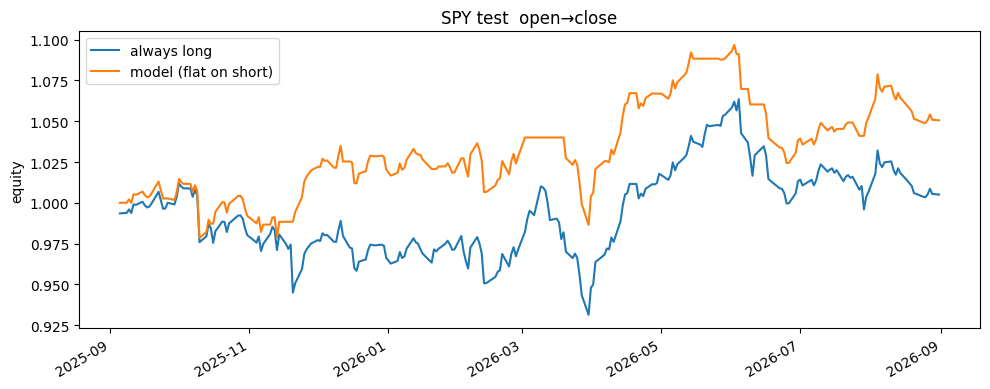

In [ ]:
proba = model.predict(X_test_s, verbose=0).ravel()
pred_long = proba >= 0.55
print(
    f"test acc={(pred_long == y_test).mean():.3f}  "
    f"always_long={y_test.mean():.3f}  "
    f"persist={(prev_test == y_test).mean():.3f}  "
    f"days_in={pred_long.mean():.3f}"
)

eq_always = np.cumprod(1.0 + ret_test)
eq_model = np.cumprod(np.where(pred_long, 1.0 + ret_test, 1.0))
print(f"always long {eq_always[-1]:.3f}  model {eq_model[-1]:.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_test, eq_always, label="always long")
ax.plot(times_test, eq_model, label="model (flat on short)")
ax.set_ylabel("equity")
ax.set_title(f"{SYMBOL} test  open→close")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


always long 1.005  long and short 1.095


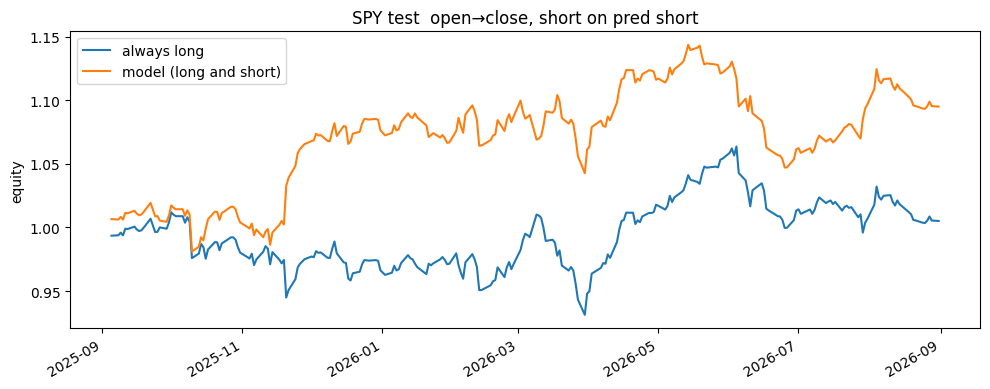

In [50]:
side = np.where(pred_long, 1.0, -1.0)
eq_both = np.cumprod(1.0 + side * ret_test)
print(f"always long {eq_always[-1]:.3f}  long and short {eq_both[-1]:.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_test, eq_always, label="always long")
ax.plot(times_test, eq_both, label="model (long and short)")
ax.set_ylabel("equity")
ax.set_title(f"{SYMBOL} test  open→close, short on pred short")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

field                        Open    High     Low   Close
timestamp                                                
2026-02-02 05:00:00+00:00  689.58  696.93  69.005  695.41


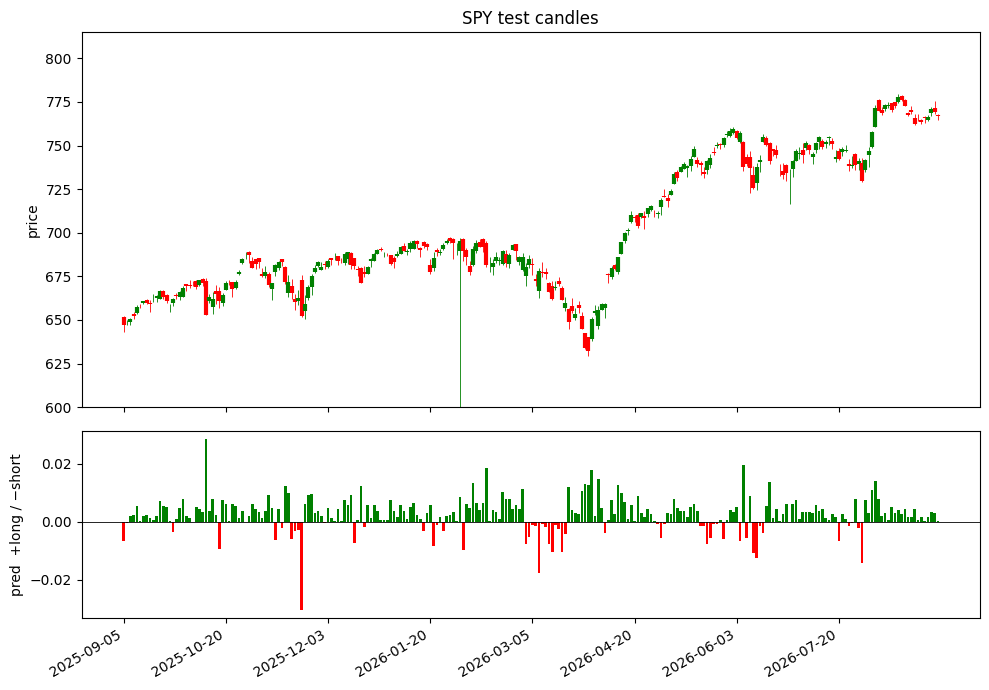

In [51]:
ohlc = df.loc[times_test, ["Open", "High", "Low", "Close"]]
o = ohlc["Open"].to_numpy()
h = ohlc["High"].to_numpy()
l = ohlc["Low"].to_numpy()
c = ohlc["Close"].to_numpy()
x = np.arange(len(ohlc))
up = c >= o

fig, (ax_c, ax_b) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, height_ratios=[2, 1])
for i in x:
    color = "green" if up[i] else "red"
    ax_c.vlines(i, l[i], h[i], color=color, linewidth=0.6)
    ax_c.vlines(i, min(o[i], c[i]), max(o[i], c[i]), color=color, linewidth=3)
ax_c.set_ylabel("price")
ax_c.set_title(f"{SYMBOL} test candles")
ax_c.set_ylim(600, ax_c.get_ylim()[1])
bad = np.flatnonzero(l < 600)
if len(bad):
    print(ohlc.iloc[bad])

signed = np.where(pred_long, np.abs(ret_test), -np.abs(ret_test))
ax_b.bar(x, signed, color=np.where(pred_long, "green", "red"), width=0.8)
ax_b.axhline(0, color="black", linewidth=0.6)
ax_b.set_ylabel("pred  +long / −short")

step = max(len(x) // 8, 1)
ax_b.set_xticks(x[::step])
ax_b.set_xticklabels([times_test[i].date().isoformat() for i in x[::step]], rotation=30, ha="right")
fig.tight_layout()
plt.show()